In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, dblquad
from scipy.special import jn,jn_zeros
plt.style.use('bmh')

La solución con velocidad inicial nula es de la forma
$$
\Psi(\rho,\varphi,t)= \sum_{m=-\infty}^\infty\sum_{n=1}^\infty a_{mn} J_m \left(\frac{\alpha_{mn}}{a}\rho\right)e^{im\varphi}e^{i\omega_{mn} t}
$$
con
$$
\omega_{mn}=\frac{v}{a}\alpha_{mn}
$$
y
$$
a_{mn}=\frac{1}{\pi a^2 [J_{m+1}(\alpha_{mn})]^2} \int_{\varphi=0}^{2\pi}\int_{\rho=0}^a\Psi_0(\rho,\varphi)J_m \left(\frac{\alpha_{mn}}{a}\rho \right)e^{-im\varphi}\rho d\rho d\varphi.
$$


In [2]:
a = 1
v = 1

In [3]:
#Se define el n-ésimo cero de la función de Bessel $J_{m}$
def alpha(m,n):
    return jn_zeros(m,n)[-1]

Como caso particular consideraremos la función "rara", dependiente tanto de $\rho$ como de $\varphi$, dada por
$$
\Psi_0(\rho,\varphi) = \left(1-\left|\frac{2\rho}{a}-1\right|\right)\frac{1}{2-\sin(\varphi)}
$$

In [4]:
def psi0(rho,phi):
    return (1-np.absolute(2*rho/a-1))/(2-np.sin(phi))

In [5]:
def complex_int(func, a, b, c, d, *args):
    def real_func(th, ph,*args):
        return func(th, ph, *args).real
    def imag_func(th, ph,*args):
        return func(th, ph, *args).imag
    real_integral = dblquad(real_func, a, b, lambda rho: c, lambda rho: d,*args)
    imag_integral = dblquad(imag_func, a, b, lambda phi: c, lambda phi: d,*args)
    return (real_integral[0] + 1j*imag_integral[0])
def int_a_mn(rho,phi,m,n):
    return (1/(np.pi*a**2*jn(m+1,alpha(m,n))**2))*psi0(rho,phi)*jn(m,(alpha(m,n)/a)*rho)*np.e**(-m*phi*1j)*rho

In [6]:
def a_mn(m,n):
    return complex_int(int_a_mn, 0, 2*np.pi, 0, a, (m, n))

In [7]:
def damn(mmax,nmax):
    damn = {}
    for m in range(-mmax,mmax+1):
        for n in range(1,nmax+1):
            damn['%d,%d'%(m,n)]=a_mn(m,n)
    return damn

In [8]:
mmax = 5 # número máximo de m en que se cortará la serie
nmax = 10 # número máximo de ceros
da_mn = damn(mmax,nmax)

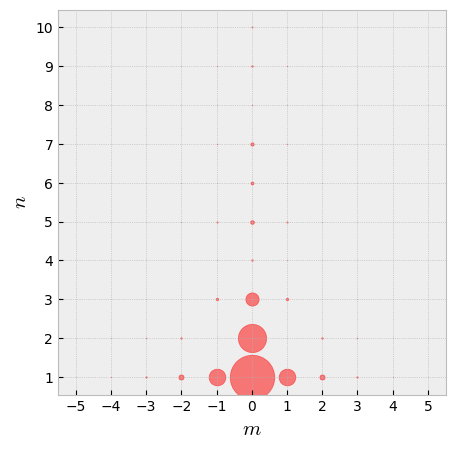

In [9]:
plt.figure(figsize=(5,5))
for m in range(-mmax,mmax+1):
    for n in range(1,nmax+1):
        plt.scatter(m,n,s=3000*np.abs(da_mn['%d,%d'%(m,n)])**2, color='red', alpha=0.5)
plt.xlabel('$m$', fontsize=15)
plt.ylabel('$n$', fontsize=15)
plt.xticks(range(-mmax,mmax+1))
plt.yticks(range(1,nmax+1))
plt.grid(ls='dotted')
plt.show()

Calculamos la suma de los términos, de acuerdo a la ec. (1)

In [10]:
def sm(rho,phi,t):
    sm = 0
    for m in range(-mmax,mmax+1):
        for n in range(1,nmax+1):
            sm += da_mn['%d,%d'%(m,n)]*jn(m,(alpha(m,n)/a)*rho)*np.e**(m*phi*1j)*np.cos((v/a)*alpha(m,n)*t)
    return sm

In [11]:
n_ang = 120 # número de divisiones de la coordenada angular
n_radio = 50 # número de divisiones de la coordenada radial
radio = np.linspace(0, a, n_radio) #se define coordenada radial entre 0 y R
ang = np.linspace(0, 2*np.pi, n_ang) #se define coordenada angular entre 0 y 2 veces pi
RHO, PHI = np.meshgrid(radio,ang)
X = RHO*np.cos(PHI) #Definiendo dominio en x
Y = RHO*np.sin(PHI) #Definiendo dominio en y

In [12]:
def grafica_disco_color(f,titulo):
    fig = plt.figure(figsize=(6,5))
    im = plt.pcolormesh(X, Y, f, vmin=-1, vmax=1, shading='gouraud')
    plt.xlabel('$x$',fontsize=15)
    plt.ylabel('$y$',fontsize=15)
    plt.title(titulo,fontsize=15)
    plt.colorbar()
    plt.show()

In [13]:
def grafica_disco_sup(f,titulo):
    ax = plt.figure(figsize=(5.5,5)).add_subplot(projection='3d')
    ax.plot_surface(X, Y, f, rstride=1, cstride=1, antialiased=False)
    plt.xlabel('$x$',fontsize=15)
    plt.ylabel('$y$',fontsize=15)
    plt.xticks(np.arange(-1,1.1,0.5))
    plt.yticks(np.arange(-1,1.1,0.5))
    plt.title(titulo,fontsize=15)
    ax.set_zticks(np.arange(-1,1.1,0.5))
    ax.set_zlim(-1.1,1.1)
    plt.show()

In [14]:
PSI0 = psi0(RHO,PHI)

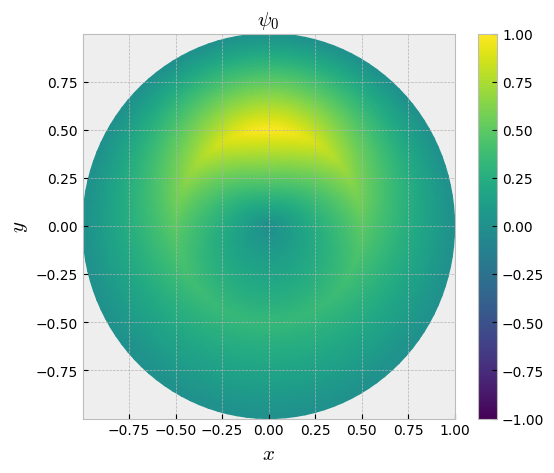

In [15]:
grafica_disco_color(PSI0,'$\\psi_{0}$')

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
C:\Users\josei\AppData\Local\Temp\ipykernel_29636\2384442344.py:1: SyntaxWarning: invalid escape sequence '\p'
  grafica_disco_sup(PSI0,'$\psi_{0}$')


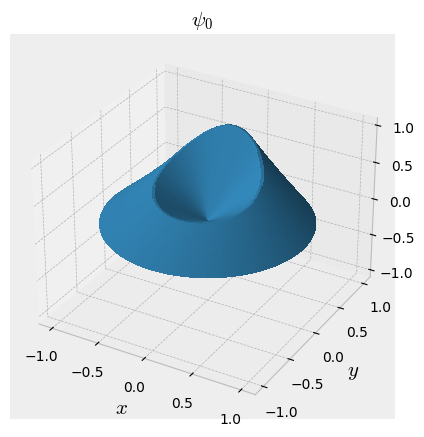

In [16]:
grafica_disco_sup(PSI0,'$\psi_{0}$')

In [17]:
from ipywidgets import interact

In [18]:
def g_color(time=0):
    grafica_disco_color(sm(RHO,PHI,time).real,'$Re[\\psi(x,y,%4.2f)]$'%time)

In [19]:
interact(g_color,time=(0.,0.15,0.01))

interactive(children=(FloatSlider(value=0.0, description='time', max=0.15, step=0.01), Output()), _dom_classes…

<function __main__.g_color(time=0)>

In [20]:
def g_color_sup(time=0):
    grafica_disco_sup(sm(RHO,PHI,time).real,'$Re[\\psi(x,y,%4.2f)]$'%time)

In [21]:
interact(g_color_sup,time=(0.,10,0.01))

interactive(children=(FloatSlider(value=0.0, description='time', max=10.0, step=0.01), Output()), _dom_classes…

<function __main__.g_color_sup(time=0)>

In [22]:
w0 = v*alpha(0,1)/a
T0 = 2*np.pi/w0
print('Periodo de oscilación más pequeño =',T0)

Periodo de oscilación más pequeño = 2.6127405736655325


In [23]:
# crea hacer un .gif animado. -delay 10 = 10 x 10^{-2} (10 centésimas de segundo), -loop 0 para que vuelva siempre al comienzo
#!convert -delay 5 -loop 0 gr2-*.png gr2-ani.gif

In [24]:
from matplotlib.animation import FuncAnimation

In [25]:
def crea_animacion():
    fig = plt.figure(figsize=(5.5,5))
    ax = fig.add_subplot(projection='3d')

    # animation function
    def animate(i):
        t = (2*T0/200)*i
        animate.p.remove()
        animate.p = ax.plot_surface(X, Y, sm(RHO,PHI,t).real,
                                    rstride=1, cstride=1, color='C0', antialiased=False)
        return animate.p,

    animate.p = ax.plot_surface(X, Y, sm(RHO,PHI,0).real, 
                                rstride=1, cstride=1, color='C0', antialiased=False)
    ax.set_zlim(-1.1,1.1)
    ax.set_xlabel('$x$',fontsize=15)
    ax.set_ylabel('$y$',fontsize=15)
    ax.set_title('$\\Psi(\\rho,\\varphi,t)$',fontsize=15)
    ax.set_xticks(np.arange(-1,1.1,0.5))
    ax.set_yticks(np.arange(-1,1.1,0.5))
    ax.set_zticks(np.arange(-1,1.1,0.5))
    anim = FuncAnimation(fig, animate, interval=50, frames=200, repeat=True, blit=True)
    anim.save('onda-disco-funcion-rara-ani.gif', dpi=100)

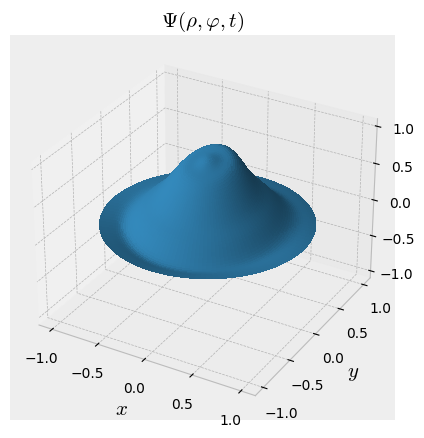

In [26]:
crea_animacion()